In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Load House 1.csv to Load House 1.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
file_path = "Load House 1.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (111068, 6)


,Date,Hour,Day of the Week,Season,Daytime,Consumption (kW)
0,2021-03-01,00:00:00,0,1,0,0.096
1,2021-03-01,00:15:00,0,1,0,0.196
2,2021-03-01,00:30:00,0,1,0,0.128
3,2021-03-01,00:45:00,0,1,0,0.156
4,2021-03-01,01:00:00,0,1,0,0.096


In [ ]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Hour"])

df = df.sort_values("datetime").reset_index(drop=True)

print(df.head())
print(df.info())

         Date      Hour  Day of the Week  Season  Daytime  Consumption (kW)  \
0  2021-03-01  00:00:00                0       1        0             0.096   
1  2021-03-01  00:15:00                0       1        0             0.196   
2  2021-03-01  00:30:00                0       1        0             0.128   
3  2021-03-01  00:45:00                0       1        0             0.156   
4  2021-03-01  01:00:00                0       1        0             0.096   

             datetime  
0 2021-03-01 00:00:00  
1 2021-03-01 00:15:00  
2 2021-03-01 00:30:00  
3 2021-03-01 00:45:00  
4 2021-03-01 01:00:00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111068 entries, 0 to 111067
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              111068 non-null  object        
 1   Hour              111068 non-null  object        
 2   Day of the Week   111068 non-null  int64      

In [ ]:
data = df[["datetime", "Consumption (kW)"]].copy()
data.rename(columns={"Consumption (kW)": "consumption"}, inplace=True)

print(data.head())
print(data.isnull().sum())

             datetime  consumption
0 2021-03-01 00:00:00        0.096
1 2021-03-01 00:15:00        0.196
2 2021-03-01 00:30:00        0.128
3 2021-03-01 00:45:00        0.156
4 2021-03-01 01:00:00        0.096
datetime       0
consumption    0
dtype: int64


In [ ]:
# combine duplicate timestamps
data = data.groupby("datetime", as_index=False)["consumption"].mean()

# create complete 15-min timeline
full_time = pd.date_range(
    start=data["datetime"].min(),
    end=data["datetime"].max(),
    freq="15min"
)

data = data.set_index("datetime").reindex(full_time)
data.index.name = "datetime"

# fill missing values
data["consumption"] = data["consumption"].interpolate(method="time")
data["consumption"] = data["consumption"].ffill().bfill()

data = data.reset_index()

print("Cleaned shape:", data.shape)
print(data.isnull().sum())

print("\nTime gap check:")
print(data["datetime"].diff().value_counts().head())

Cleaned shape: (111073, 2)
datetime       0
consumption    0
dtype: int64

Time gap check:
datetime
0 days 00:15:00    111072
Name: count, dtype: int64


In [ ]:
hourly_data = data.copy()
hourly_data = hourly_data.set_index("datetime")

hourly_data = hourly_data.resample("1H").mean()

hourly_data = hourly_data.interpolate(method="time")
hourly_data = hourly_data.ffill().bfill()

hourly_data = hourly_data.reset_index()

print("Hourly shape:", hourly_data.shape)
print(hourly_data.head())

print("\nHourly gap check:")
print(hourly_data["datetime"].diff().value_counts().head())

Hourly shape: (27769, 2)
             datetime  consumption
0 2021-03-01 00:00:00        0.144
1 2021-03-01 01:00:00        0.075
2 2021-03-01 02:00:00        0.126
3 2021-03-01 03:00:00        0.063
4 2021-03-01 04:00:00        0.082

Hourly gap check:
datetime
0 days 01:00:00    27768
Name: count, dtype: int64


/tmp/ipykernel_3255/3212782757.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = hourly_data.resample("1H").mean()


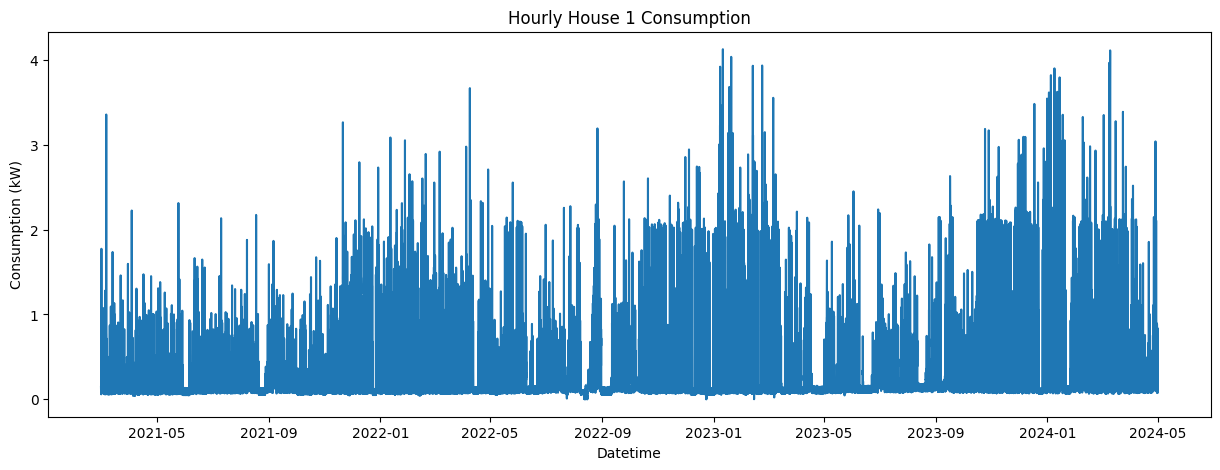

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(hourly_data["datetime"], hourly_data["consumption"])
plt.title("Hourly House 1 Consumption")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kW)")
plt.show()

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, arr, seq_len, pred_len):
        self.arr = arr.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.arr) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.arr[idx : idx + self.seq_len]
        y = self.arr[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.tensor(x), torch.tensor(y)


def prepare_loaders(hourly_data, seq_len=24, pred_len=1, batch_size=64):
    n = len(hourly_data)

    train_size = int(n * 0.7)
    val_size = int(n * 0.15)

    train_df = hourly_data.iloc[:train_size].copy()
    val_df = hourly_data.iloc[train_size:train_size + val_size].copy()
    test_df = hourly_data.iloc[train_size + val_size:].copy()

    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train_df[["consumption"]])
    val_scaled = scaler.transform(val_df[["consumption"]])
    test_scaled = scaler.transform(test_df[["consumption"]])

    train_ds = TimeSeriesDataset(train_scaled, seq_len, pred_len)
    val_ds = TimeSeriesDataset(val_scaled, seq_len, pred_len)
    test_ds = TimeSeriesDataset(test_scaled, seq_len, pred_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler

In [ ]:
class PatchTST(nn.Module):
    def __init__(
        self,
        seq_len=24,
        pred_len=1,
        patch_len=4,
        stride=2,
        d_model=64,
        n_heads=4,
        e_layers=3,
        dropout=0.1
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_len = patch_len
        self.stride = stride

        self.num_patches = ((seq_len - patch_len) // stride) + 1

        self.patch_embed = nn.Linear(patch_len, d_model)

        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches, d_model)
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            enc_layer,
            num_layers=e_layers
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.num_patches * d_model, pred_len)
        )

    def forward(self, x):
        x = x.squeeze(-1)

        patches = x.unfold(
            dimension=1,
            size=self.patch_len,
            step=self.stride
        )

        patches = self.patch_embed(patches)
        patches = patches + self.pos_embed

        out = self.encoder(patches)
        out = self.head(out)

        return out.unsqueeze(-1)

In [ ]:
loss_fn = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = loss_fn(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            loss = loss_fn(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)


def test_model(model, loader, scaler, device):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)

            all_preds.append(out.cpu().numpy())
            all_true.append(y.numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    pred_flat = all_preds.reshape(-1, 1)
    true_flat = all_true.reshape(-1, 1)

    pred_inv = scaler.inverse_transform(pred_flat)
    true_inv = scaler.inverse_transform(true_flat)

    mae = mean_absolute_error(true_inv, pred_inv)
    mse = mean_squared_error(true_inv, pred_inv)

    return mae, mse, true_inv, pred_inv

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

seq_len = 24
batch_size = 64
epochs = 10

pred_lens = [1, 8, 16, 24]

results = {}

for pred_len in pred_lens:
    print("\n" + "="*50)
    print(f"Training PatchTST for {pred_len} hour forecast")
    print("="*50)

    train_loader, val_loader, test_loader, scaler = prepare_loaders(
        hourly_data,
        seq_len=seq_len,
        pred_len=pred_len,
        batch_size=batch_size
    )

    model = PatchTST(
        seq_len=seq_len,
        pred_len=pred_len,
        patch_len=4,
        stride=2,
        d_model=64,
        n_heads=4,
        e_layers=3,
        dropout=0.1
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float("inf")
    best_model_path = f"best_patchtst_{pred_len}.pth"

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss = validate(model, val_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    model.load_state_dict(torch.load(best_model_path, map_location=device))

    mae, mse, true_inv, pred_inv = test_model(
        model,
        test_loader,
        scaler,
        device
    )

    results[pred_len] = {
        "MAE": mae,
        "MSE": mse,
        "true": true_inv,
        "pred": pred_inv,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

    print(f"\nPatchTST {pred_len} hour forecast")
    print("MAE:", mae)
    print("MSE:", mse)

Device: cpu

Training PatchTST for 1 hour forecast
Epoch [1/10] Train Loss: 0.554220 | Val Loss: 0.443350
Epoch [2/10] Train Loss: 0.487847 | Val Loss: 0.431356
Epoch [3/10] Train Loss: 0.469226 | Val Loss: 0.447594
Epoch [4/10] Train Loss: 0.458088 | Val Loss: 0.412175
Epoch [5/10] Train Loss: 0.445351 | Val Loss: 0.432085
Epoch [6/10] Train Loss: 0.437441 | Val Loss: 0.405159
Epoch [7/10] Train Loss: 0.428044 | Val Loss: 0.421070
Epoch [8/10] Train Loss: 0.430721 | Val Loss: 0.404642
Epoch [9/10] Train Loss: 0.418676 | Val Loss: 0.403387
Epoch [10/10] Train Loss: 0.418854 | Val Loss: 0.412063

PatchTST 1 hour forecast
MAE: 0.2709142863750458
MSE: 0.20579513907432556

Training PatchTST for 8 hour forecast
Epoch [1/10] Train Loss: 0.764101 | Val Loss: 0.557251
Epoch [2/10] Train Loss: 0.718644 | Val Loss: 0.587301
Epoch [3/10] Train Loss: 0.696957 | Val Loss: 0.550261
Epoch [4/10] Train Loss: 0.681687 | Val Loss: 0.540187
Epoch [5/10] Train Loss: 0.669141 | Val Loss: 0.552670
Epoch [6/

In [ ]:
result_df = pd.DataFrame({
    "Forecast Type": [
        "Single-step 1 hour",
        "Multi-step 8 hours",
        "Multi-step 16 hours",
        "Multi-step 24 hours"
    ],
    "Prediction Length": [1, 8, 16, 24],
    "MAE": [results[p]["MAE"] for p in [1, 8, 16, 24]],
    "MSE": [results[p]["MSE"] for p in [1, 8, 16, 24]]
})

result_df

,Forecast Type,Prediction Length,MAE,MSE
0,Single-step 1 hour,1,0.270914,0.205795
1,Multi-step 8 hours,8,0.379297,0.340980
2,Multi-step 16 hours,16,0.386953,0.353017
3,Multi-step 24 hours,24,0.403922,0.367246


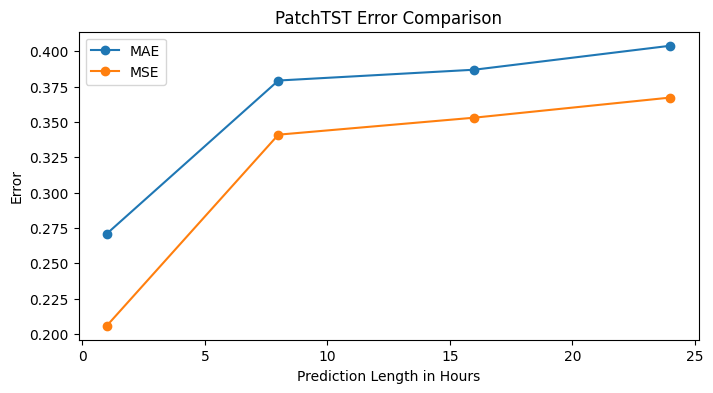

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(result_df["Prediction Length"], result_df["MAE"], marker="o", label="MAE")
plt.plot(result_df["Prediction Length"], result_df["MSE"], marker="o", label="MSE")
plt.xlabel("Prediction Length in Hours")
plt.ylabel("Error")
plt.title("PatchTST Error Comparison")
plt.legend()
plt.show()

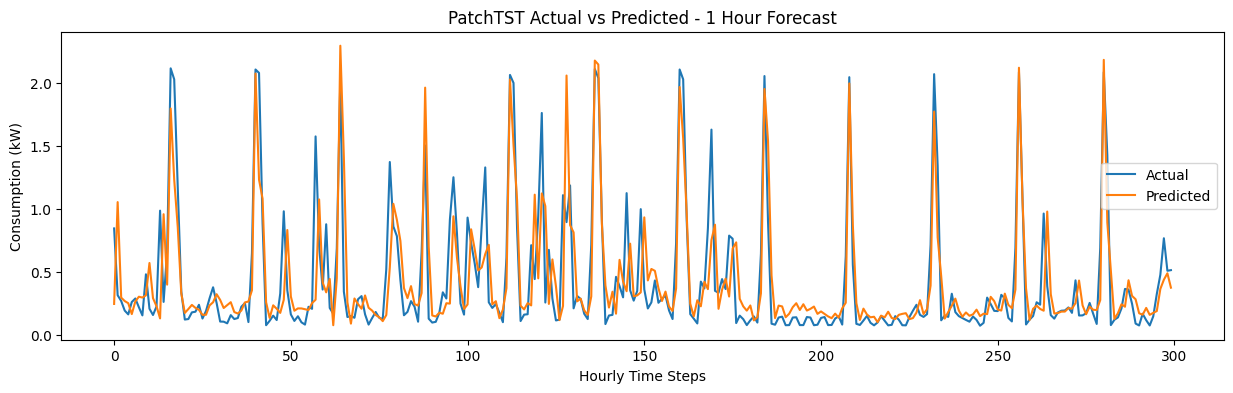

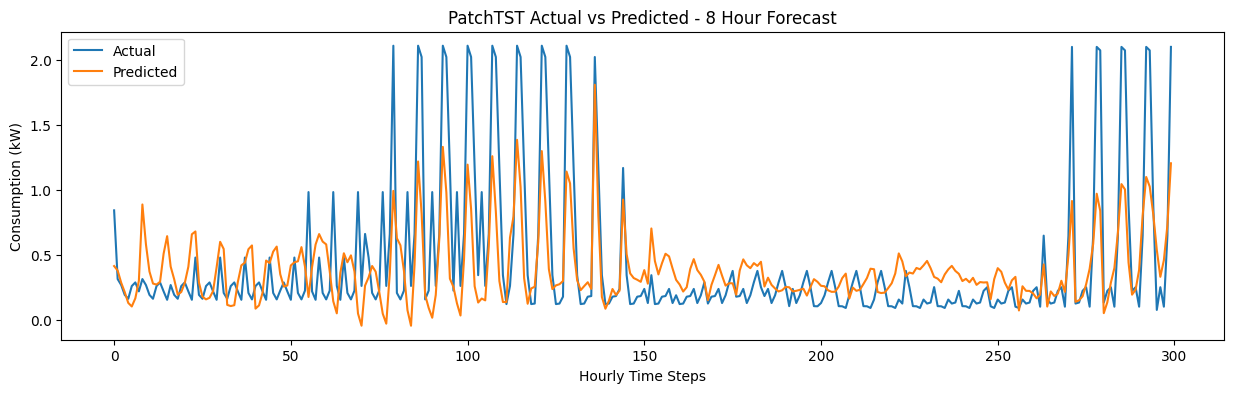

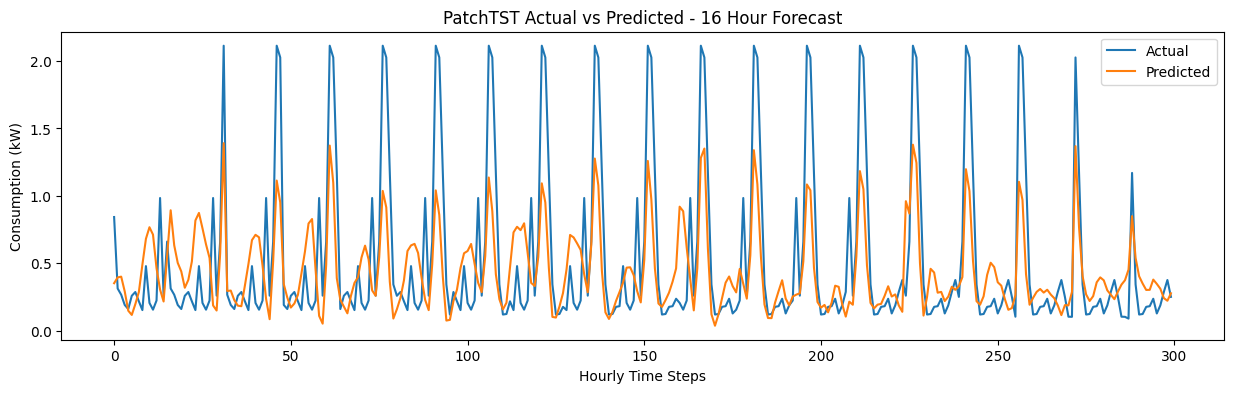

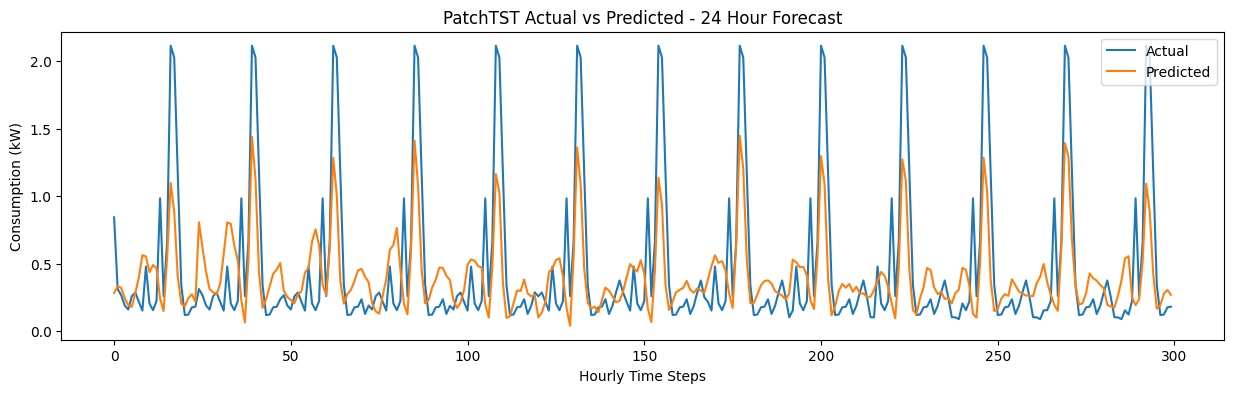

In [ ]:
for pred_len in [1, 8, 16, 24]:
    true_vals = results[pred_len]["true"].reshape(-1)
    pred_vals = results[pred_len]["pred"].reshape(-1)

    plt.figure(figsize=(15, 4))
    plt.plot(true_vals[:300], label="Actual")
    plt.plot(pred_vals[:300], label="Predicted")
    plt.title(f"PatchTST Actual vs Predicted - {pred_len} Hour Forecast")
    plt.xlabel("Hourly Time Steps")
    plt.ylabel("Consumption (kW)")
    plt.legend()
    plt.show()